<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea Módulo VI - Aprendizaje No Supervisado**

**Metodologías:**

*   Principal Component Analysis (PCA)
*   t-Distributed Stochastic Neighbor Embedding (t-SNE)
*   Uniform Manifold Approximation and Projection (UMAP)

**PENDIENTES**

"Codificar categorías .. No One Hoted ... era ???

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéric
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer
import umap
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings("ignore")

import umap # Importamos la librería que acabas de instalar
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Importar la información  ya limpia y normalizada
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')
print(df_habits.shape)
print(df_habits.head(3))
print(df_habits.info())

(1000, 15)
   age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0   23  Female                  0.0                 1.2            1.1   
1   20  Female                  6.9                 2.8            2.3   
2   21    Male                  1.4                 3.1            1.3   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   

   exercise_frequency parental_education_level internet_quality  \
0                   6                   Master          Average   
1                   6              High School          Average   
2                   1              High School             Poor   

   mental_health_rating extracurricular_participation  exam_score  
0                     8                           Yes        56.2  
1             

In [3]:
#Podría haber diferentes decisiones:
# Opción 1: Considerar no utilizar parental_education_level
# Opción 2: Imputar parental_education_level
# Opción 2: Eliminar los 91 registros de lainformación (~10%)

df_habits.isnull().sum()

age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

#PRIMERA SECCIÓN

## EDA

Análisis de las variables cuantitativas
1.   Descripción en tabla
2.   Visualización mediante gráficos de caja y bigotes e histogramas

Análisis de las variables cualitativas
1.   Elemento de lista
2.   Visualización mediante gráficos de barras




In [4]:
# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64'])
cols_cuantitativas.describe().round(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,20.498,3.550,2.506,1.820,84.132,6.470,3.042,5.438,69.602
std,2.308,1.469,1.172,1.075,9.399,1.226,2.025,2.848,16.889
min,17.000,0.000,0.000,0.000,56.000,3.200,0.000,1.000,18.400
25%,18.750,2.600,1.700,1.000,78.000,5.600,1.000,3.000,58.475
50%,20.000,3.500,2.500,1.800,84.400,6.500,3.000,5.000,70.500
75%,23.000,4.500,3.300,2.525,91.025,7.300,5.000,8.000,81.325
max,24.000,8.300,7.200,5.400,100.000,10.000,6.000,10.000,100.000


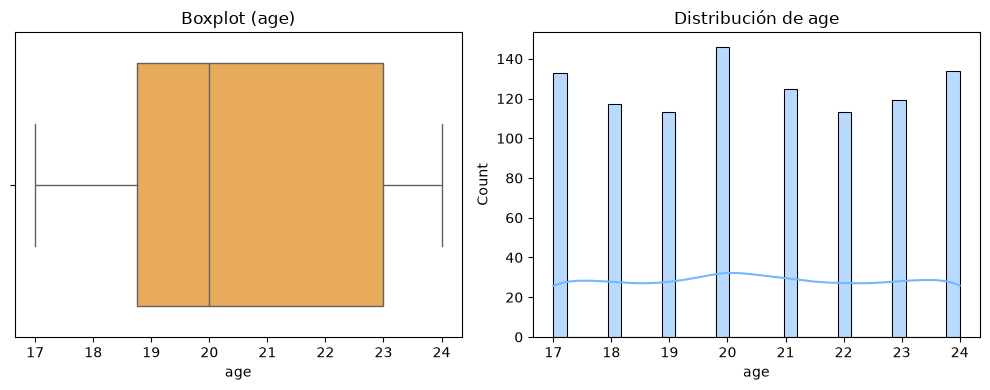

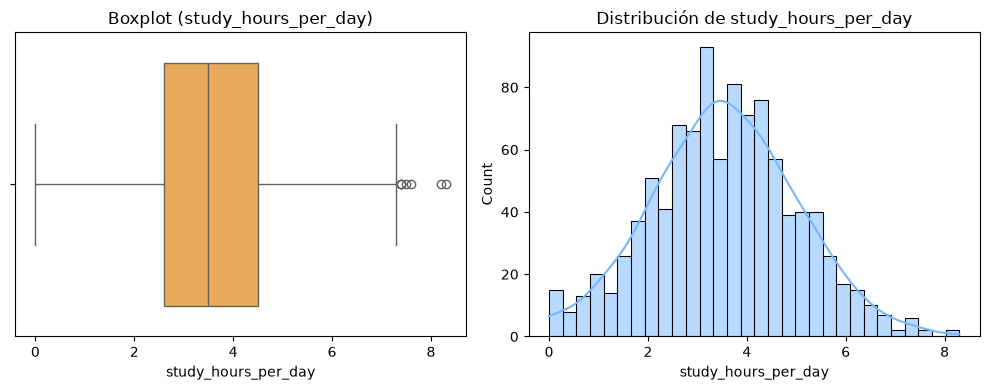

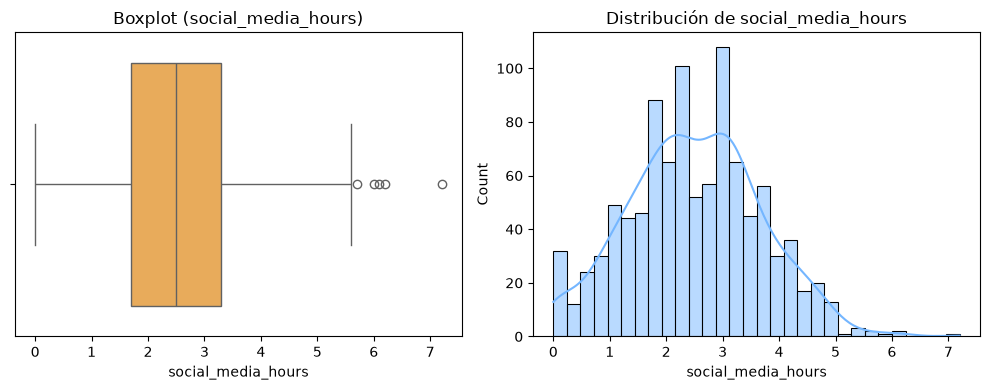

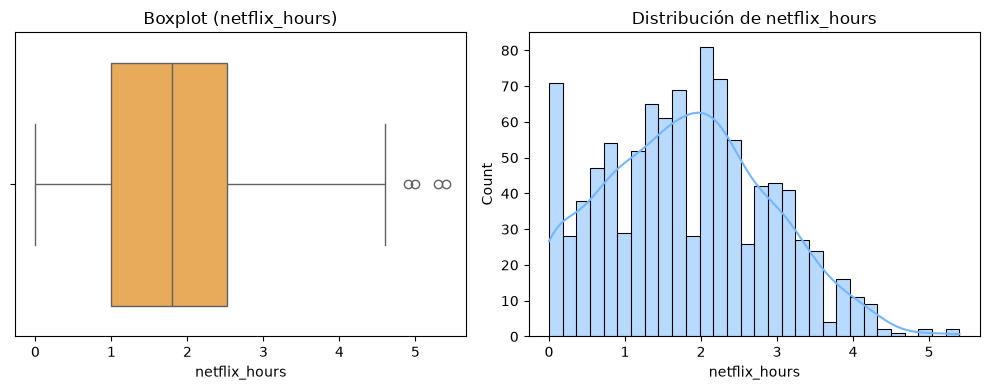

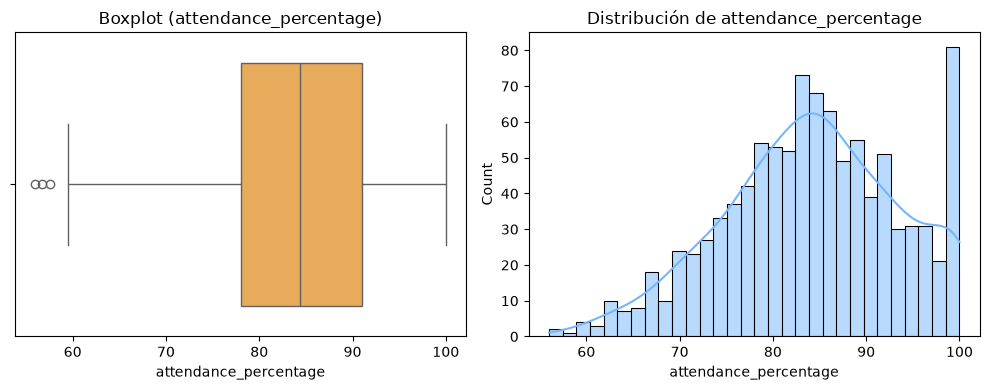

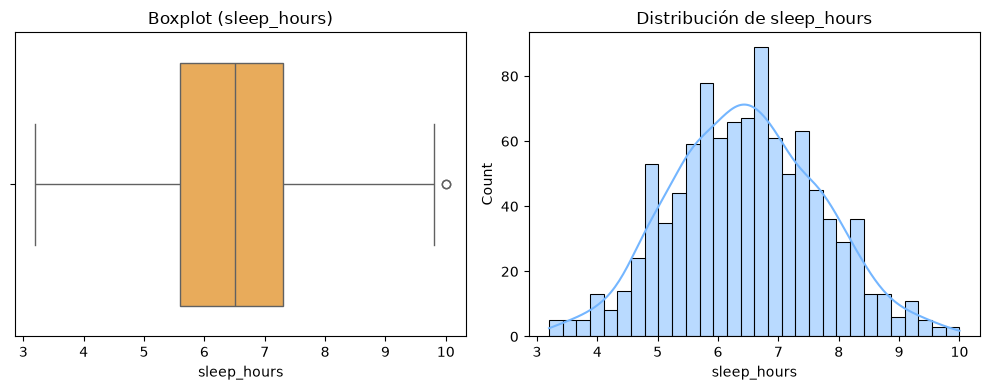

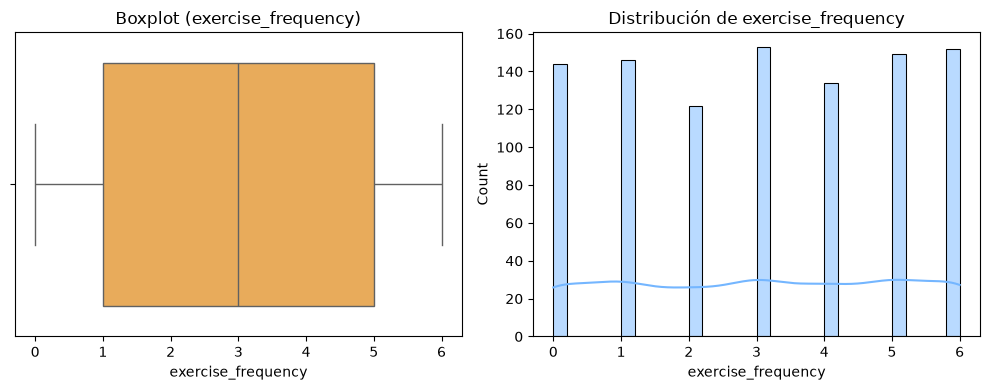

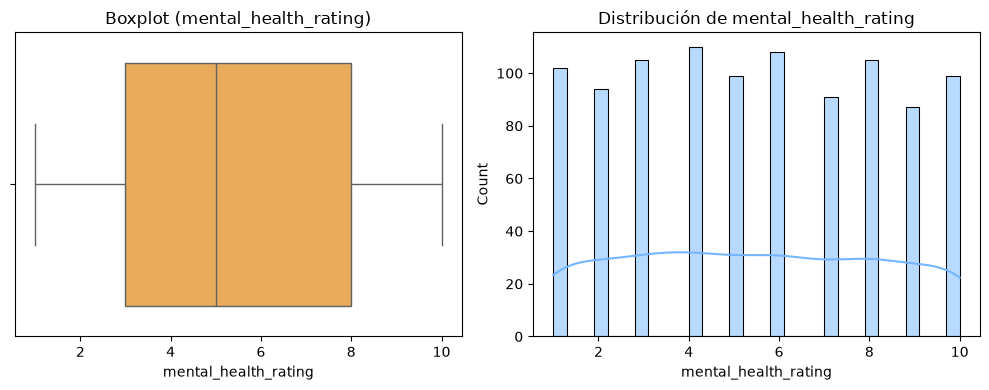

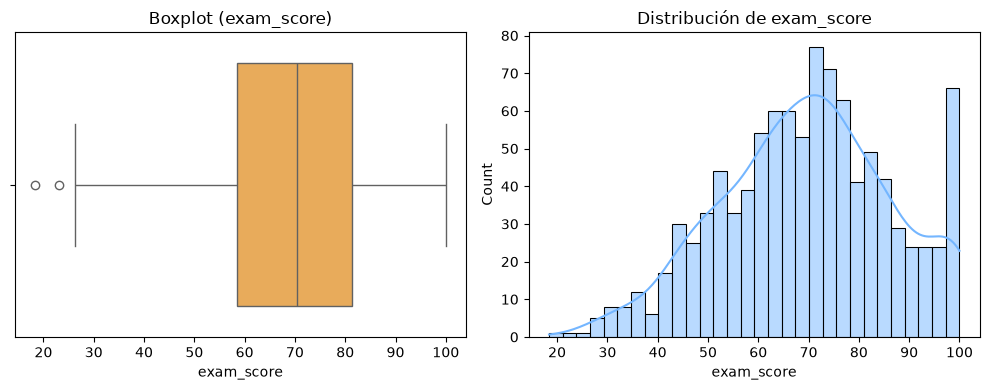

In [5]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES PARA VARIABLES CUANTITATIVA

# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64']).columns.tolist()
#cols_cuantitativas = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
#                      "attendande_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating ",
#                      "exam_score"
#                      ]

# Iterar sobre cada columna y graficar
for col in cols_cuantitativas:
    plt.figure(figsize=(10, 4))  # tamaño de la figura

    #Gráfico de caja y bigotes
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_habits[col], color="#ffae44") #  palette="viridis"
    plt.title(f"Boxplot ({col})")

    # Gráfico para el histograma identificar sesgos o valores atípicos (outliers)
    plt.subplot(1, 2, 2)
    sns.histplot(df_habits[col], bins=30, color="#74b6ff", kde=True) #palette="viridis"
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

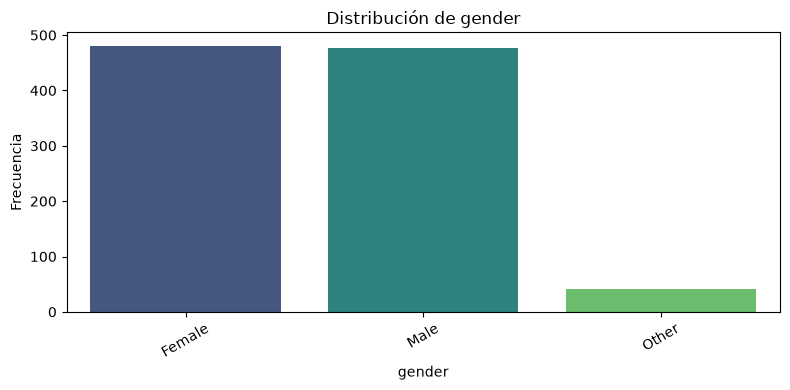

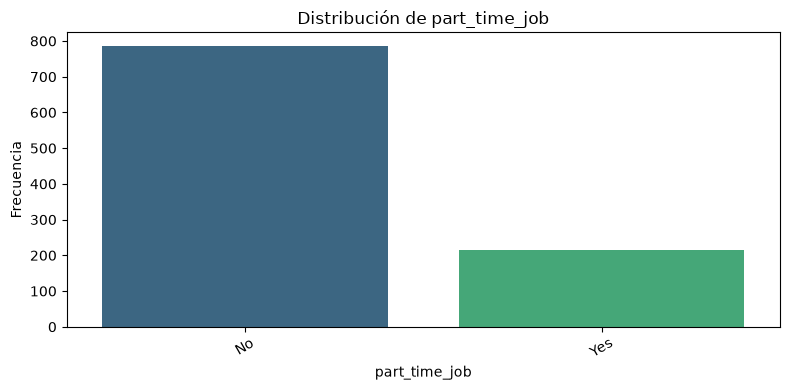

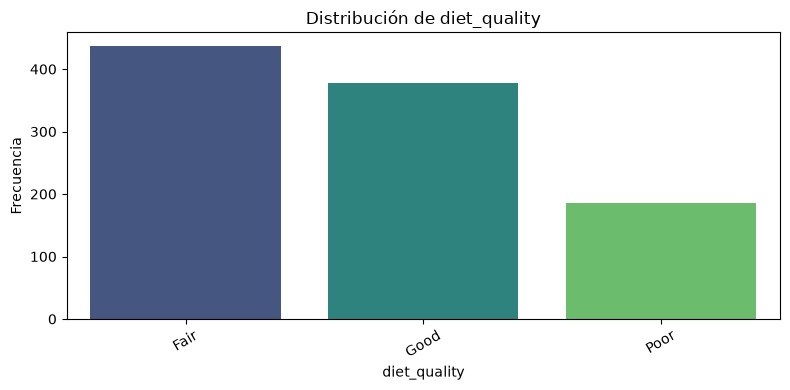

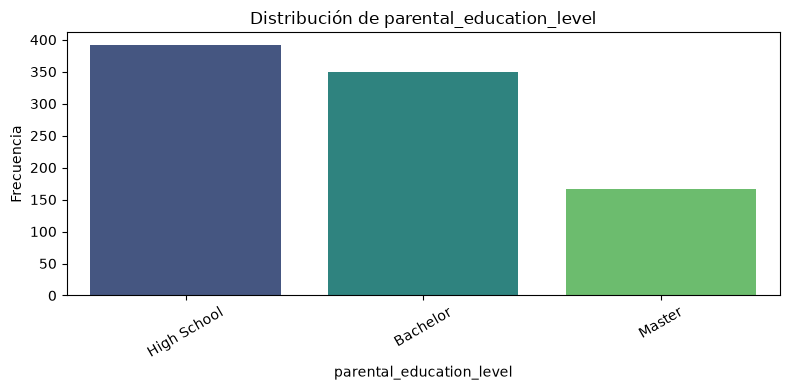

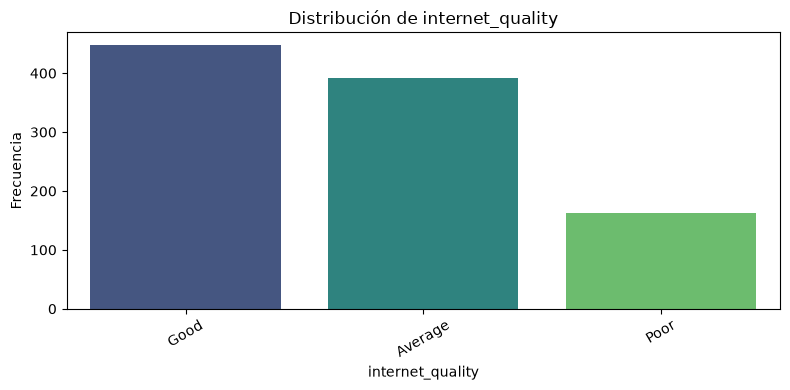

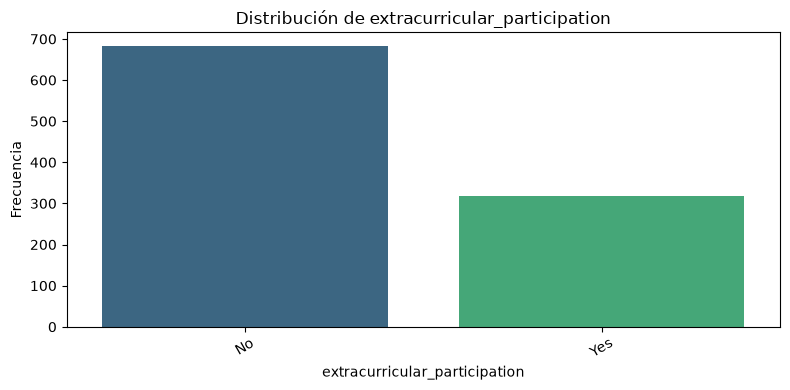

In [6]:
# GRAFICO  DE BARRAS PARA VARIABLES CUALITATIVA

# Lista de columnas cuantitativas a analizar
cols_cualitativas = df_habits.select_dtypes(include=['object', 'category']).columns.tolist()

# Iterar sobre cada columna y graficar
for col in cols_cualitativas:
    plt.figure(figsize=(8, 4))

    # Conteo de categorías
    counts = df_habits[col].value_counts()

    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")
    plt.xlabel(col)
    plt.xticks(rotation=30)  # rotar etiquetas si son largas

    plt.tight_layout()
    plt.show()

# Preprocesamiento y Modelos de agrup...




In [7]:
# Aqui observamos los datos unicos por columna.
cols = pd.Series(df_habits.columns)

for i in cols:
    print("Columna: ", i)
    display(df_habits[i].unique())
    print("\n")


Columna:  age


array([23, 20, 21, 19, 24, 18, 22, 17])



Columna:  gender


<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str



Columna:  study_hours_per_day


...

array([ 8,  1,  4, 10,  3,  9,  7,  5,  2,  6])



Columna:  extracurricular_participation


<StringArray>
['Yes', 'No']
Length: 2, dtype: str



Columna:  exam_score


array([ 56.2, 100. ,  34.3,  26.8,  66.4,  89.8,  72.6,  78.9,  63.3,
        74.4,  76.9,  75.8,  74. ,  55.2,  70.8,  43.9,  45.3,  58.5,
        82.5,  98.7,  43.7,  54.9,  69.9,  73.5,  71.1,  82.8,  75.7,
        70.6,  51.3,  52.1,  70.7,  51.2,  59.4,  58.1,  82.3,  69.7,
        66. ,  63.5,  65.7,  78.5,  75.1,  71. ,  59.7,  52.6,  96.5,
        62. ,  48.4,  68.1,  87.2,  66.7,  75.2,  46.4,  97.1,  61.2,
        75. ,  94.7,  77.6,  68.6,  69.6,  66.5,  62.2,  82.1,  55.1,
        77.1,  97.7,  66.9,  99.9,  57.2,  77.3,  91.6,  57.6,  60.2,
        50.5,  53.5,  79.2,  47.2,  73.4,  41.1,  77.8,  63.4,  70.2,
        81.3,  50.2,  87.9,  80.9,  63.9,  65.6,  93.2,  60.8,  50.4,
        74.3,  32.8,  60.4,  60. ,  77.5,  86.5,  83.3,  82.7,  94.8,
        80.8,  58.3,  66.3,  60.5,  84.8,  77. ,  61.7,  44. ,  42.4,
        88. ,  48.7,  81.6,  78.4,  67.6,  64.7,  64.1,  83.5,  96.2,
        65.4,  46.7,  75.5,  78.1,  85.2,  75.4,  64.2,  90.3,  81.4,
        65. ,  57.3,

In [8]:
exam_scores = df_habits['exam_score'].copy()

X = df_habits.copy()

# esto es mejor que el one-hot, dado que mantenemos más baja la dimensionalidad
X['part_time_job'] = X['part_time_job'].map({'No': 0, 'Yes': 1})
X['extracurricular_participation'] = X['extracurricular_participation'].map({'No': 0, 'Yes': 1})

diet_categories = ['Poor', 'Fair', 'Good']
internet_categories = ['Poor', 'Average', 'Good']
# Observamos la columna parental_education_level es la única con NaN.
# Cambiamos NaN a string "Unknown"
education_categories = ['High School', 'Bachelor', 'Master', "Unknown"]

col_education = ['parental_education_level']
cols_other_ordinal = ['diet_quality', 'internet_quality']
cols_nominal = ['gender']
cols_numeric = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 
                'attendance_percentage', 'sleep_hours', 'exercise_frequency', 
                'mental_health_rating', 'part_time_job', 'extracurricular_participation',
               'exam_score']

education_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ordinal', OrdinalEncoder(categories=[education_categories]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numeric),
        ('edu_ord', education_pipeline, col_education), # Usamos education_pipline
        ('other_ord', OrdinalEncoder(categories=[diet_categories, internet_categories]), cols_other_ordinal),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), cols_nominal)
    ],
    remainder='passthrough'
)

pipeline_final = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler_final', StandardScaler())
])

X_procesado_array = pipeline_final.fit_transform(X)

In [9]:
# Esto es simplemente para ver el dataframe trasformado, por si nos es útil para el reporte
# ya que los piplines lo convierte a arranges abstractos sin nombres.

nombres_columnas = pipeline_final.named_steps['preprocess'].get_feature_names_out()
df_procesado = pd.DataFrame(X_procesado_array, columns=nombres_columnas)

display(df_procesado.head())

,num__age,num__study_hours_per_day,num__social_media_hours,num__netflix_hours,num__attendance_percentage,num__sleep_hours,num__exercise_frequency,num__mental_health_rating,num__part_time_job,num__extracurricular_participation,num__exam_score,edu_ord__parental_education_level,other_ord__diet_quality,other_ord__internet_quality,nom__gender_Male,nom__gender_Other
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,-0.523341,1.464464,-0.793922,1.086723,-0.266175,-0.392302,-0.955011,-0.209383
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,-0.523341,-0.682844,1.800846,-0.997118,1.112970,-0.392302,-0.955011,-0.209383
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,-0.523341,-0.682844,-2.091307,-0.997118,-1.645320,-1.768800,1.047108,-0.209383
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,-0.523341,1.464464,-2.535616,1.086723,-1.645320,0.984196,-0.955011,-0.209383
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,-0.523341,-0.682844,-0.189661,1.086723,-0.266175,0.984196,-0.955011,-0.209383


## Modelitos: Reducción de dimensionalidad

### PCA

Al aplicar el Análisis de Componentes Principales (PCA), los primeros dos componentes lograron retener únicamente el 16.23% de la varianza total de los datos originales. Lejos de ser un error, este resultado es un hallazgo analítico importante: nos indica que el comportamiento de los estudiantes (sus hábitos) es un fenómeno de alta dimensionalidad con muy baja correlación lineal. No existen dos "super-hábitos" que resuman todo el perfil del estudiante. Esto justifica plenamente la necesidad de explorar modelos no lineales como t-SNE y UMAP a continuación, los cuales son más capaces de desenredar relaciones complejas.

Varianza explicada: Componente 1: 12.16%, Componente 2: 7.98%
Total de información retenida en 2D: 20.14%


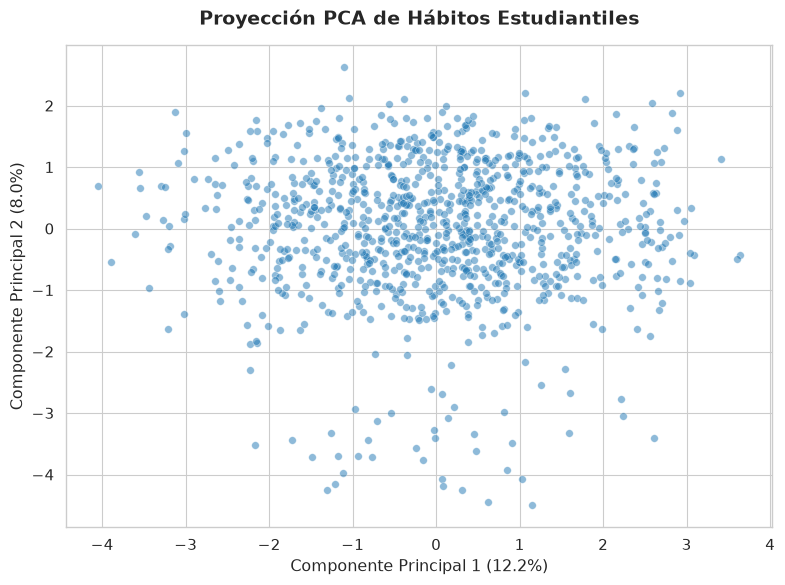

In [10]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_procesado_array)

var_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada: Componente 1: {var_explicada[0]*100:.2f}%, Componente 2: {var_explicada[1]*100:.2f}%")
print(f"Total de información retenida en 2D: {(var_explicada[0] + var_explicada[1])*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],   
    color='#1f77b4',
    alpha=0.5,
    s=30
)
plt.title('Proyección PCA de Hábitos Estudiantiles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)')
plt.tight_layout()

plt.show()

# Para guardar el la imagen: plt.savefig('nombre.pdf', bbox_inches='tight')

### t-SNE

La proyección no lineal mediante t-SNE revela una topología subyacente fascinante en los datos. A diferencia de las limitaciones del PCA, t-SNE logra identificar una estructura local sumamente clara: un micro-clúster fuertemente aislado en el extremo izquierdo del plano bidimensional. Esto sugiere empíricamente la existencia de un subgrupo de estudiantes con un perfil conductual altamente atípico y homogéneo. Por otro lado, la macrorregión central demuestra que el grueso de la población estudiantil se distribuye en un continuo multidimensional. Las variaciones de densidad dentro de esta gran nube (sub-nodos más compactos interconectados por regiones dispersas) indican que el comportamiento estudiantil no está polarizado de forma binaria, un factor crucial a considerar cuando se apliquen algoritmos de agrupamiento aglomerativo en fases posteriores.

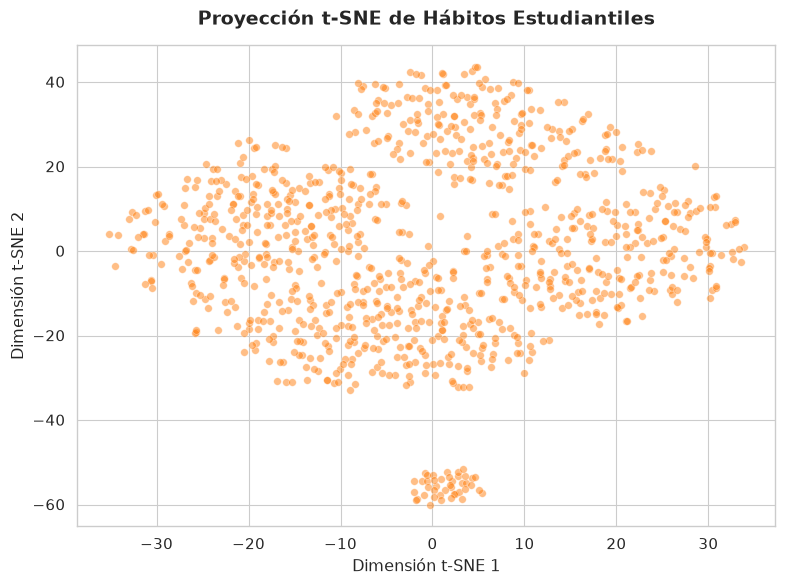

In [11]:
# Nota: La 'perplexity' (perplejidad) es clave aquí. 
# Controla cuántos "vecinos" considera el algoritmo. 
tsne = TSNE(n_components=2, perplexity=30, random_state=42) 
X_tsne = tsne.fit_transform(X_procesado_array)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    color='#ff7f0e',
    alpha=0.5,
    s=30
)
plt.title('Proyección t-SNE de Hábitos Estudiantiles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.tight_layout()

plt.show()


### UMAP

Al aplicar UMAP, observamos que la nube de datos general logra fragmentarse en clústers visualmente más definidos y cohesionados. Dado que UMAP es superior preservando la estructura topológica global de los datos, esta fragmentación nos confirma empíricamente la existencia de distintos "perfiles de hábitos" entre los estudiantes.

Sin embargo, las técnicas de reducción de dimensiones son herramientas de visualización geométrica, no de perfilado. Para descubrir las características subyacentes de estos grupos (es decir, qué hábitos específicos de estudio, sueño o uso de redes sociales definen a cada clúster), es imperativo aplicar algoritmos de agrupamiento (Clustering) sobre el espacio multidimensional, lo cual será el enfoque de la siguiente fase del análisis.

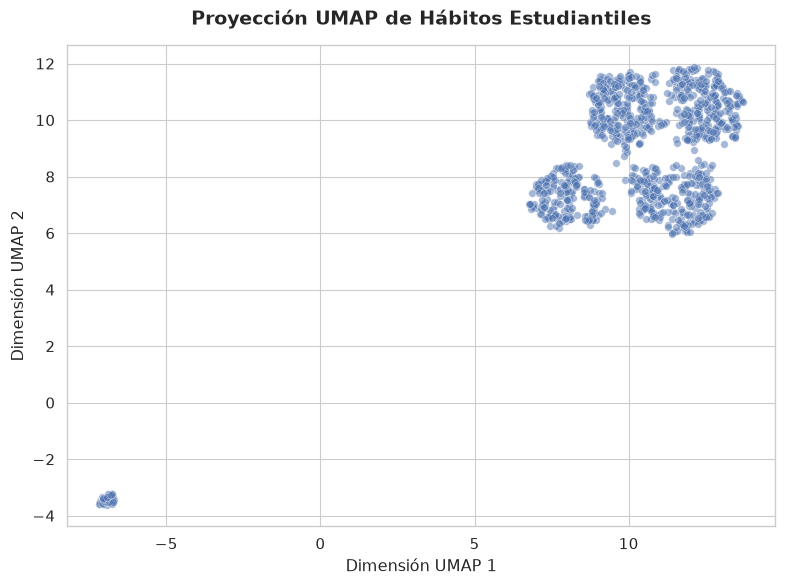

In [13]:

# n_neighbors (parecido a perplexity en t-SNE) y min_dist:
# controlan qué tan "apretados" se ven los grupos
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_procesado_array)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    alpha=0.5,
    s=30
)
plt.title('Proyección UMAP de Hábitos Estudiantiles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.tight_layout()

plt.show()

## Modelitos: Agrupamiento de variables

### K-means:

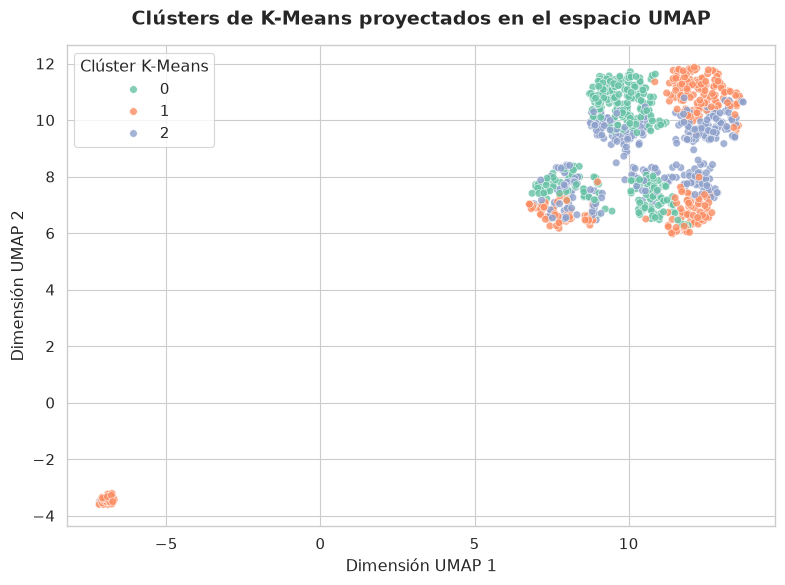


--- TABLA DE ANÁLISIS DE PERFILES (K-MEANS) ---
         study_hours_per_day  sleep_hours  social_media_hours  \
Cluster                                                         
0                        4.2          6.5                 2.4   
1                        4.3          6.6                 2.4   
2                        2.1          6.3                 2.7   

         attendance_percentage  exam_score  
Cluster                                     
0                         84.5        78.1  
1                         85.1        79.1  
2                         82.7        51.2  


In [14]:

# 1. Entrenar el modelo K-Means
# Asignaremos 3 clústers (K=3) como un buen punto de partida empírico
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
etiquetas_kmeans = kmeans.fit_predict(X_procesado_array)

# 2. Visualización Profesional: K-Means proyectado sobre UMAP
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Coloreamos los puntos de UMAP usando las etiquetas que K-Means acaba de inventar
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=etiquetas_kmeans, 
                palette='Set2', s=30, alpha=0.8)

plt.title('Clústers de K-Means proyectados en el espacio UMAP', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend(title='Clúster K-Means')
plt.tight_layout()
plt.show()

# 3. Preparar los datos para nuestro análisis (La carnita del reporte)
df_analisis = df_habits.copy() # Tomamos tu dataframe original (el que tiene los datos reales)
df_analisis['exam_score'] = exam_scores # Le regresamos la calificación que le habíamos quitado
df_analisis['Cluster'] = etiquetas_kmeans # Le pegamos la etiqueta de K-Means

# Calculamos el promedio de cada grupo. 
# round(1) lo deja con un solo decimal para que sea fácil de leer en tu consola
resumen_kmeans = df_analisis.groupby('Cluster').mean(numeric_only=True).round(1)

print("\n--- TABLA DE ANÁLISIS DE PERFILES (K-MEANS) ---")
# Imprimimos las columnas más críticas para ver cómo afectan la calificación
print(resumen_kmeans[['study_hours_per_day', 'sleep_hours', 'social_media_hours', 'attendance_percentage', 'exam_score']])

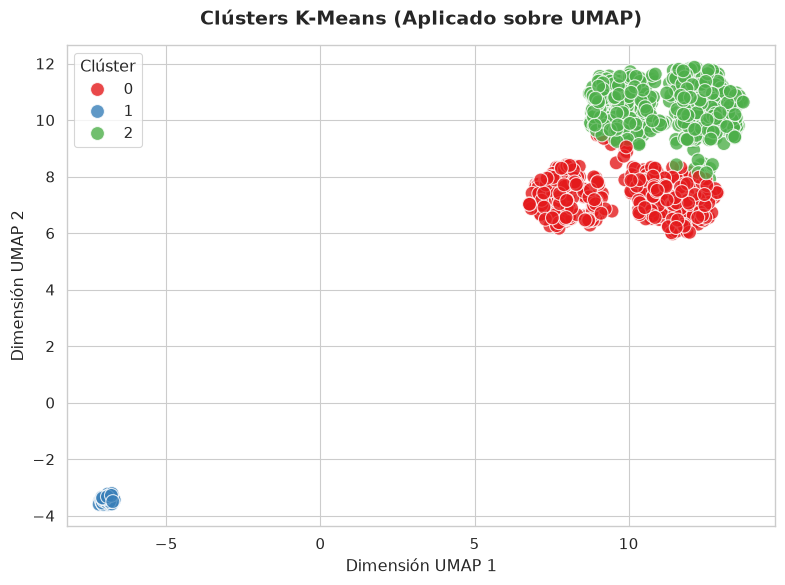


--- NUEVA TABLA DE PERFILES ---
         study_hours_per_day  sleep_hours  social_media_hours  \
Cluster                                                         
0                        3.5          6.5                 2.5   
1                        3.6          6.8                 2.6   
2                        3.6          6.4                 2.5   

         attendance_percentage  exam_score  
Cluster                                     
0                         83.6        69.8  
1                         84.1        70.6  
2                         84.6        69.3  


In [15]:

# 1. El truco maestro: Entrenar K-Means SOBRE las coordenadas de UMAP
kmeans_mejorado = KMeans(n_clusters=3, random_state=42, n_init=10)
# ¡OJO AQUÍ! Cambiamos X_procesado_array por X_umap
etiquetas_mejoradas = kmeans_mejorado.fit_predict(X_umap)

# 2. Visualización: Ahora sí deberían coincidir los colores con las formas
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=etiquetas_mejoradas, 
                palette='Set1', s=100, alpha=0.8)

plt.title('Clústers K-Means (Aplicado sobre UMAP)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend(title='Clúster')
plt.tight_layout()
plt.show()

# 3. La nueva tabla de análisis
df_analisis_mejorado = df_habits.copy()
df_analisis_mejorado['exam_score'] = exam_scores 
df_analisis_mejorado['Cluster'] = etiquetas_mejoradas 

resumen_mejorado = df_analisis_mejorado.groupby('Cluster').mean(numeric_only=True).round(1)

print("\n--- NUEVA TABLA DE PERFILES ---")
print(resumen_mejorado[['study_hours_per_day', 'sleep_hours', 'social_media_hours', 'attendance_percentage', 'exam_score']])

In [ ]:
# Eliminando valores missing
habits_nomiss = df_habits.dropna()
print(habits_nomiss)

In [ ]:
# UMAP sin especificar hiper-parámetros (valores por defecto)

# tomamos las variables numericas
numeric_cols = habits_nomiss.select_dtypes(include=[np.number]).columns
# print(numeric_cols)
Scaled_habits_data = StandardScaler().fit_transform(habits_nomiss[numeric_cols])
# print(type(Scaled_habits_data), Scaled_habits_data.shape)

reducer = umap.UMAP(random_state=42) # con semilla, para que no mueva los resultados
df_umap = reducer.fit_transform(Scaled_habits_data)
# Resultados
print(type(df_umap), df_umap.shape)
print(df_umap[:5])

# # Version pingüinos
# plt.scatter(
#     df_umap[:, 0],
#     df_umap[:, 1],
#     c=[sns.color_palette()[x] for x in habits_nomiss[["age"]]])
# plt.gca().set_aspect('equal', 'datalim')
# plt.title('UMAP projection of the Penguin dataset', fontsize=24);

In [ ]:
# Para que podamos tomar la variable de "Calificaciones" la segmentamos en quartiles:
habits_nomiss["exam_quartile"] = pd.qcut(
    habits_nomiss["exam_score"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

bins = [0, 3, 5.9, 8, 10]   # límites de los intervalos
labels = ["0-3", "3-5.9", "6-8", "8-10"]

# Verificar resultado
print(habits_nomiss[["exam_score", "exam_quartile"]].head())

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_quartile"],   # aquí pasas la variable
    palette="viridis",          # paleta de colores
    s=50                        # tamaño de los puntos
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset', fontsize=16)
plt.legend(title="exam_quartile")
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_score"],   # variable categórica
    palette="Set2",             # paleta discreta (Set1, Set2, Paired, etc.)
    s=60
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection by exam_score category', fontsize=16)
plt.legend(title="exam_score category")
plt.show()

In [ ]:
habits_nomiss[["gender"]]
#  ({"Female":0,"Male":1,"Other":2})